In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data=pd.read_csv("tips.csv")
bill=np.array(data.total_bill)
tip=np.array(data.tip)

In [4]:
def kernel(point,xmat,k):
    m,n=np.shape(xmat)
    weights=np.asmatrix(np.eye(m))
    for j in range(m):
        diff=point-xmat[j]
        weights[j,j]=np.exp((diff*diff.T)/(-2.0*k**2)).item()
    return weights
def localWeight(point,xmat,ymat,k):
    wei=kernel(point,xmat,k)
    W=(xmat.T*(wei*xmat)).I*(xmat.T*(wei*ymat.T))
    return W
def localWeightRegression(xmat,ymat,k):
    m,n=np.shape(xmat)
    ypred=np.zeros(m)
    for i in range(m):
        ypred[i]=(xmat[i]*localWeight(xmat[i],xmat,ymat,k)).item()
    return ypred
mbill=np.asmatrix(bill)
mtip=np.asmatrix(tip)
m=np.shape(mbill)[1]
one=np.asmatrix(np.ones(m))
X=np.hstack((one.T,mbill.T))
ypred=localWeightRegression(X,mtip,0.5)
SortIndex=X[:,1].argsort(0)
xsort=X[SortIndex][:,0]

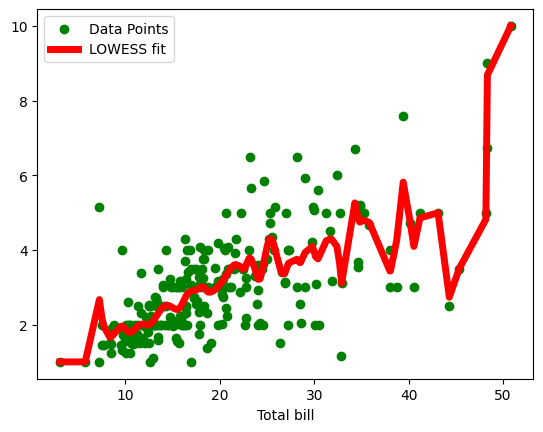

In [6]:
fig=plt.figure()
ax=fig.add_subplot(1,1,1)
ax.scatter(bill,tip,color='green',label='Data Points')
x_axis_line=np.squeeze(np.asarray(xsort[:,1]))
y_axis_line=np.squeeze(np.asarray(ypred[SortIndex]))
ax.plot(x_axis_line,y_axis_line,color='red',linewidth=5,label='LOWESS fit')
plt.xlabel('Total bill')
plt.legend()
plt.savefig("exercise6.png")
plt.show()